In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohameddawoud/ecommerce-ab-testing")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ecommerce-ab-testing' dataset.
Path to dataset files: /kaggle/input/ecommerce-ab-testing


In [59]:
print(path)
from pathlib import Path

data_path = Path("/root/.cache/kagglehub/datasets/ahmedmohameddawoud/ecommerce-ab-testing/versions/1")

list(data_path.iterdir())

/kaggle/input/ecommerce-ab-testing


[PosixPath('/root/.cache/kagglehub/datasets/ahmedmohameddawoud/ecommerce-ab-testing/versions/1/ab_test.csv'),
 PosixPath('/root/.cache/kagglehub/datasets/ahmedmohameddawoud/ecommerce-ab-testing/versions/1/countries_ab.csv')]

In [60]:
import pandas as pd
import numpy as np
from pathlib import Path

data_path = Path(path)
csv_path = next(data_path.glob("*.csv"))
df = pd.read_csv(csv_path)
print(df.shape)
print(df.columns)
df.head(10)



(294478, 5)
Index(['id', 'time', 'con_treat', 'page', 'converted'], dtype='object')


,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1
5,936923,20:49.1,control,old_page,0
6,679687,26:46.9,treatment,new_page,1
7,719014,48:29.5,control,old_page,0
8,817355,58:09.0,treatment,new_page,1
9,839785,11:06.6,treatment,new_page,1


In [61]:
# Check data types and missing values
df.info()
df.isnull().sum()

print("\n")

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate user IDs: {df['id'].duplicated().sum()}")

print("\n")
# Basic summary
print(f"\nVariant distribution:")
print(df['con_treat'].value_counts())
print(f"\nPage distribution:")
print(df['page'].value_counts())
print(f"\nConversion distribution:")
print(df['converted'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         294478 non-null  int64 
 1   time       294478 non-null  object
 2   con_treat  294478 non-null  object
 3   page       294478 non-null  object
 4   converted  294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


Duplicate rows: 0
Duplicate user IDs: 3894



Variant distribution:
con_treat
treatment    147276
control      147202
Name: count, dtype: int64

Page distribution:
page
old_page    147239
new_page    147239
Name: count, dtype: int64

Conversion distribution:
converted
0    259241
1     35237
Name: count, dtype: int64


In [62]:
# Check if treatment assignment matches page shown
# Control should see old_page, treatment should see new_page
assignment_check = df.groupby(['con_treat', 'page']).size().unstack(fill_value=0)
print("Assignment vs Page shown:")
print(assignment_check)

# Check for mismatches
mismatches = df[
    ((df['con_treat'] == 'control') & (df['page'] == 'new_page')) |
    ((df['con_treat'] == 'treatment') & (df['page'] == 'old_page'))
]
print(f"\nMismatched assignments: {len(mismatches)}")

Assignment vs Page shown:
page       new_page  old_page
con_treat                    
control        1928    145274
treatment    145311      1965

Mismatched assignments: 3893


In [63]:
# Remove mismatched assignments
df_clean = df[
    ~(((df['con_treat'] == 'control') & (df['page'] == 'new_page')) |
      ((df['con_treat'] == 'treatment') & (df['page'] == 'old_page')))
].copy()

print(f"Rows after removing mismatches: {len(df_clean)}")

# Remove duplicate user IDs (keep first occurrence)
df_clean = df_clean.drop_duplicates(subset='id', keep='first')

print(f"Rows after removing duplicates: {len(df_clean)}")

# Verify clean assignment
print("\nClean assignment check:")
print(df_clean.groupby(['con_treat', 'page']).size().unstack(fill_value=0))

# Final group sizes
print(f"\nFinal sample sizes:")
print(df_clean['con_treat'].value_counts())

Rows after removing mismatches: 290585
Rows after removing duplicates: 290584

Clean assignment check:
page       new_page  old_page
con_treat                    
control           0    145274
treatment    145310         0

Final sample sizes:
con_treat
treatment    145310
control      145274
Name: count, dtype: int64


## Data Cleaning

We removed two types of problematic rows:

**1. Mismatched assignments (3,893 rows)**

Users who were assigned to control but saw the new page, or assigned to treatment but saw the old page. These are implementation errors where the assignment didn't match what the user actually experienced. Including them would contaminate both groups and bias our results.

**2. Duplicate user IDs (after removing mismatches)**

Some users appear multiple times in the dataset. This violates the independence assumption required for statistical tests. We keep only the first occurrence of each user to ensure each observation is independent.

After cleaning, we have a proper A/B test where:
- Control group only saw old_page
- Treatment group only saw new_page  
- Each user appears exactly once

In [64]:
# Sample Ratio Mismatch (SRM) Check
from scipy import stats

# Expected 50/50 split
n_total = len(df_clean)
n_control = len(df_clean[df_clean['con_treat'] == 'control'])
n_treatment = len(df_clean[df_clean['con_treat'] == 'treatment'])

expected_control = n_total / 2
expected_treatment = n_total / 2

# Chi-square goodness of fit test
observed = [n_control, n_treatment]
expected = [expected_control, expected_treatment]

chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"Observed: Control={n_control}, Treatment={n_treatment}")
print(f"Expected: Control={expected_control:.0f}, Treatment={expected_treatment:.0f}")
print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value > 0.05:
    print("\nSRM Check: PASSED. Sample sizes are balanced as expected.")
else:
    print("\nSRM Check: FAILED. Sample sizes are significantly imbalanced.")

Observed: Control=145274, Treatment=145310
Expected: Control=145292, Treatment=145292

Chi-square statistic: 0.0045
P-value: 0.9468

SRM Check: PASSED. Sample sizes are balanced as expected.


In [65]:
# Basic conversion rates by variant
conversion_summary = df_clean.groupby('con_treat').agg({
    'converted': ['sum', 'count', 'mean']
}).round(4)

conversion_summary.columns = ['conversions', 'total_users', 'conversion_rate']
conversion_summary = conversion_summary.reset_index()

print(conversion_summary)

# Calculate lift
control_rate = conversion_summary[conversion_summary['con_treat'] == 'control']['conversion_rate'].values[0]
treatment_rate = conversion_summary[conversion_summary['con_treat'] == 'treatment']['conversion_rate'].values[0]

absolute_lift = treatment_rate - control_rate
relative_lift = (treatment_rate - control_rate) / control_rate

print(f"\nControl conversion rate: {control_rate:.4f}")
print(f"Treatment conversion rate: {treatment_rate:.4f}")
print(f"Absolute lift: {absolute_lift:.4f} ({absolute_lift*100:.2f} percentage points)")
print(f"Relative lift: {relative_lift:.4f} ({relative_lift*100:.2f}%)")

   con_treat  conversions  total_users  conversion_rate
0    control        17489       145274           0.1204
1  treatment        17264       145310           0.1188

Control conversion rate: 0.1204
Treatment conversion rate: 0.1188
Absolute lift: -0.0016 (-0.16 percentage points)
Relative lift: -0.0133 (-1.33%)


In [66]:
# Pre-experiment power analysis
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize

# Using control rate as baseline
baseline_rate = control_rate
n_per_group = len(df_clean) / 2

# Calculate what MDE this sample size could detect at 80% power
# Test different effect sizes to find the MDE
test_effects = np.arange(0.001, 0.02, 0.001)
mde_found = None

for effect in test_effects:
    treatment_rate_test = baseline_rate + effect
    effect_size = proportion_effectsize(baseline_rate, treatment_rate_test)
    power = zt_ind_solve_power(effect_size=effect_size, nobs1=n_per_group,
                                alpha=0.05, alternative='two-sided')
    if power >= 0.80:
        mde_found = effect
        mde_power = power
        break

print(f"Sample size per group: {n_per_group:.0f}")
print(f"Baseline conversion rate: {baseline_rate:.4f}")
print(f"\nMinimum Detectable Effect (MDE) at 80% power:")
print(f"  Absolute: {mde_found:.4f} ({mde_found*100:.2f} percentage points)")
print(f"  Relative: {mde_found/baseline_rate:.4f} ({(mde_found/baseline_rate)*100:.2f}%)")
print(f"  Actual power at this MDE: {mde_power:.2%}")

# Calculate power for the observed effect
observed_effect_size = proportion_effectsize(control_rate, treatment_rate)
power_observed = zt_ind_solve_power(effect_size=abs(observed_effect_size),
                                     nobs1=n_per_group, alpha=0.05,
                                     alternative='two-sided')
print(f"\nPower to detect observed effect ({absolute_lift:.4f}):")
print(f"  {power_observed:.2%}")

Sample size per group: 145292
Baseline conversion rate: 0.1204

Minimum Detectable Effect (MDE) at 80% power:
  Absolute: 0.0040 (0.40 percentage points)
  Relative: 0.0332 (3.32%)
  Actual power at this MDE: 90.82%

Power to detect observed effect (-0.0016):
  26.45%


In [67]:
print("Sample time values:")
print(df_clean['time'].head(20))
print(f"\nUnique time values: {df_clean['time'].nunique()}")

Sample time values:
0     11:48.6
1     01:45.2
2     55:06.2
3     28:03.1
4     52:26.2
5     20:49.1
6     26:46.9
7     48:29.5
8     58:09.0
9     11:06.6
10    37:11.5
11    37:47.8
12    05:16.2
13    31:09.6
14    45:11.3
15    05:21.7
16    01:00.1
17    37:26.3
18    55:51.1
19    33:37.4
Name: time, dtype: object

Unique time values: 35991


## Temporal Stability Check

**Limitation:** The dataset's time column contains duration offsets (MM:SS format) rather than actual timestamps, so we cannot analyze conversion rates over calendar time or check for novelty effects. In a real experiment, this analysis would be critical to ensure the treatment effect is stable across days/weeks.

In [68]:
# Parse time as minutes:seconds offset from experiment start
def parse_time_offset(time_str):
    parts = time_str.split(':')
    minutes = int(parts[0])
    seconds = float(parts[1])
    return minutes + seconds/60  # Total minutes

df_clean['time_offset_minutes'] = df_clean['time'].apply(parse_time_offset)

print(f"Time range: {df_clean['time_offset_minutes'].min():.2f} to {df_clean['time_offset_minutes'].max():.2f} minutes")
print(f"Experiment duration: {df_clean['time_offset_minutes'].max():.2f} minutes ({df_clean['time_offset_minutes'].max()/60:.2f} hours)")

# Create time bins (quartiles)
df_clean['time_quartile'] = pd.qcut(df_clean['time_offset_minutes'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Conversion rate by quartile and variant
temporal_analysis = df_clean.groupby(['time_quartile', 'con_treat']).agg({
    'converted': ['sum', 'count', 'mean']
}).reset_index()
temporal_analysis.columns = ['quartile', 'variant', 'conversions', 'users', 'conversion_rate']

print("\nConversion rates across time periods:")
print(temporal_analysis)

Time range: 0.00 to 60.00 minutes
Experiment duration: 60.00 minutes (1.00 hours)

Conversion rates across time periods:
  quartile    variant  conversions  users  conversion_rate
0       Q1    control         4443  36198         0.122742
1       Q1  treatment         4309  36456         0.118197
2       Q2    control         4349  36440         0.119347
3       Q2  treatment         4252  36202         0.117452
4       Q3    control         4358  36265         0.120171
5       Q3  treatment         4439  36381         0.122014
6       Q4    control         4339  36371         0.119298
7       Q4  treatment         4264  36271         0.117559


/tmp/ipython-input-1241322030.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temporal_analysis = df_clean.groupby(['time_quartile', 'con_treat']).agg({


<Figure size 1000x600 with 0 Axes>

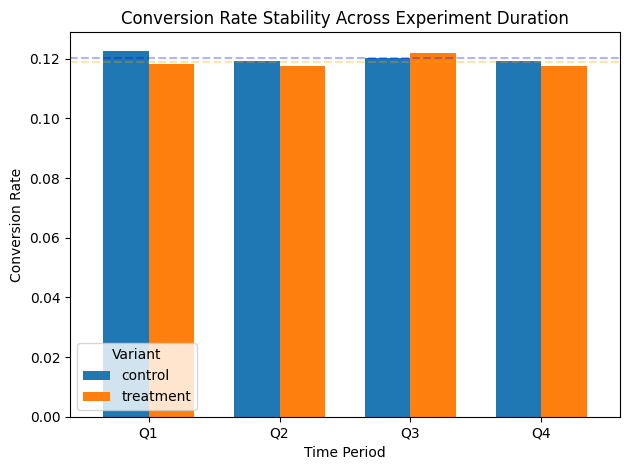


Treatment effect by time period:
Q1: -0.0045 (-0.45 percentage points)
Q2: -0.0019 (-0.19 percentage points)
Q3: 0.0018 (0.18 percentage points)
Q4: -0.0017 (-0.17 percentage points)

Effect direction changes: 1 positive, 3 negative


In [69]:
import matplotlib.pyplot as plt

# Pivot for easier plotting
pivot_temporal = temporal_analysis.pivot(index='quartile', columns='variant', values='conversion_rate')

plt.figure(figsize=(10, 6))
pivot_temporal.plot(kind='bar', width=0.7)
plt.ylabel('Conversion Rate')
plt.xlabel('Time Period')
plt.title('Conversion Rate Stability Across Experiment Duration')
plt.xticks(rotation=0)
plt.legend(title='Variant')
plt.axhline(y=control_rate, color='blue', linestyle='--', alpha=0.3, label='Overall Control')
plt.axhline(y=treatment_rate, color='orange', linestyle='--', alpha=0.3, label='Overall Treatment')
plt.tight_layout()
plt.show()

# Test if treatment effect varies across time periods
# Calculate lift per quartile
temporal_lift = pivot_temporal['treatment'] - pivot_temporal['control']
print("\nTreatment effect by time period:")
for idx, lift in temporal_lift.items():
    print(f"{idx}: {lift:.4f} ({lift*100:.2f} percentage points)")

print(f"\nEffect direction changes: {(temporal_lift > 0).sum()} positive, {(temporal_lift < 0).sum()} negative")

## Temporal Stability Analysis

**Key Finding:** The treatment effect is **highly unstable** across the experiment duration.

- Q1: -0.45 percentage points (treatment worse)
- Q2: -0.19 percentage points (treatment worse)  
- Q3: +0.18 percentage points (treatment **better**)
- Q4: -0.17 percentage points (treatment worse)

The effect changes direction in Q3, and the overall negative result (-0.16 pp) appears driven largely by Q1. This instability suggests the effect may not be a true treatment effect but rather noise. A stable, real treatment effect would show consistent direction and magnitude across time periods.

# Frequentist Approach

In [70]:
from scipy.stats import norm

# Two-proportion z-test
n_control = conversion_summary[conversion_summary['con_treat'] == 'control']['total_users'].values[0]
n_treatment = conversion_summary[conversion_summary['con_treat'] == 'treatment']['total_users'].values[0]
p_control = conversion_summary[conversion_summary['con_treat'] == 'control']['conversion_rate'].values[0]
p_treatment = conversion_summary[conversion_summary['con_treat'] == 'treatment']['conversion_rate'].values[0]

# Pooled proportion
p_pooled = (p_control * n_control + p_treatment * n_treatment) / (n_control + n_treatment)

# Standard error
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))

# Z-statistic
z_stat = (p_treatment - p_control) / se_pooled

# Two-tailed p-value
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Frequentist Two-Proportion Z-Test")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# 95% confidence interval for the difference
se_diff = np.sqrt(p_control * (1 - p_control) / n_control + p_treatment * (1 - p_treatment) / n_treatment)
ci_lower = (p_treatment - p_control) - 1.96 * se_diff
ci_upper = (p_treatment - p_control) + 1.96 * se_diff

print(f"\n95% CI for difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"95% CI for difference: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%] (percentage points)")

if p_value < 0.05:
    print("\nResult: Statistically significant at α=0.05")
else:
    print("\nResult: Not statistically significant at α=0.05")

Frequentist Two-Proportion Z-Test
Z-statistic: -1.3290
P-value: 0.1839

95% CI for difference: [-0.0040, 0.0008]
95% CI for difference: [-0.40%, 0.08%] (percentage points)

Result: Not statistically significant at α=0.05


## Frequentist Analysis Results

**Test:** Two-proportion z-test  
**Null hypothesis:** Treatment and control have equal conversion rates

**Results:**
- Z-statistic: -1.33
- P-value: 0.184
- 95% CI: [-0.40%, +0.08%] percentage points

**Interpretation:**  
We fail to reject the null hypothesis at α=0.05. There is insufficient evidence to conclude the treatment differs from control. The confidence interval includes zero, meaning the true effect could range from a 0.40 pp decrease to a 0.08 pp increase.

Combined with the temporal instability and low statistical power (26%), this suggests no meaningful difference between variants.

# Bayesian analysis:

In [71]:
import pymc as pm
import arviz as az

# Data
control_conversions = conversion_summary[conversion_summary['con_treat'] == 'control']['conversions'].values[0]
control_total = conversion_summary[conversion_summary['con_treat'] == 'control']['total_users'].values[0]
treatment_conversions = conversion_summary[conversion_summary['con_treat'] == 'treatment']['conversions'].values[0]
treatment_total = conversion_summary[conversion_summary['con_treat'] == 'treatment']['total_users'].values[0]

# Build Bayesian model
with pm.Model() as model:
    # Priors: Beta(1,1) is uniform, weakly informative
    p_control = pm.Beta('p_control', alpha=1, beta=1)
    p_treatment = pm.Beta('p_treatment', alpha=1, beta=1)

    # Likelihood
    obs_control = pm.Binomial('obs_control', n=control_total, p=p_control, observed=control_conversions)
    obs_treatment = pm.Binomial('obs_treatment', n=treatment_total, p=p_treatment, observed=treatment_conversions)

    # Derived quantities
    diff = pm.Deterministic('diff', p_treatment - p_control)
    relative_lift = pm.Deterministic('relative_lift', (p_treatment - p_control) / p_control)

    # Sample
    trace = pm.sample(2000, tune=1000, random_seed=42, return_inferencedata=True)

print("Sampling complete")

Output()

Sampling complete


In [72]:
# Posterior summaries
print("Posterior Summaries:")
print(az.summary(trace, var_names=['p_control', 'p_treatment', 'diff', 'relative_lift']))

# Probability that treatment is better than control
prob_treatment_better = (trace.posterior['diff'] > 0).values.mean()
print(f"\nP(treatment > control): {prob_treatment_better:.4f} ({prob_treatment_better*100:.2f}%)")

# Credible intervals
diff_samples = trace.posterior['diff'].values.flatten()
ci_95 = np.percentile(diff_samples, [2.5, 97.5])
print(f"95% Credible Interval for difference: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")
print(f"95% Credible Interval: [{ci_95[0]*100:.2f}%, {ci_95[1]*100:.2f}%] (percentage points)")

# Expected loss (expected regret of choosing wrong variant)
loss_if_choose_control = np.maximum(diff_samples, 0).mean()  # Loss if we choose control but treatment is better
loss_if_choose_treatment = np.maximum(-diff_samples, 0).mean()  # Loss if we choose treatment but control is better

print(f"\nExpected loss if we choose control: {loss_if_choose_control:.6f} ({loss_if_choose_control*100:.4f}%)")
print(f"Expected loss if we choose treatment: {loss_if_choose_treatment:.6f} ({loss_if_choose_treatment*100:.4f}%)")

Posterior Summaries:
                mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
p_control      0.120  0.001   0.119    0.122        0.0      0.0    3623.0   
p_treatment    0.119  0.001   0.117    0.120        0.0      0.0    4189.0   
diff          -0.002  0.001  -0.004    0.001        0.0      0.0    3994.0   
relative_lift -0.013  0.010  -0.032    0.006        0.0      0.0    3996.0   

               ess_tail  r_hat  
p_control        2551.0    1.0  
p_treatment      2879.0    1.0  
diff             2953.0    1.0  
relative_lift    2861.0    1.0  

P(treatment > control): 0.0920 (9.20%)
95% Credible Interval for difference: [-0.0041, 0.0008]
95% Credible Interval: [-0.41%, 0.08%] (percentage points)

Expected loss if we choose control: 0.000050 (0.0050%)
Expected loss if we choose treatment: 0.001669 (0.1669%)


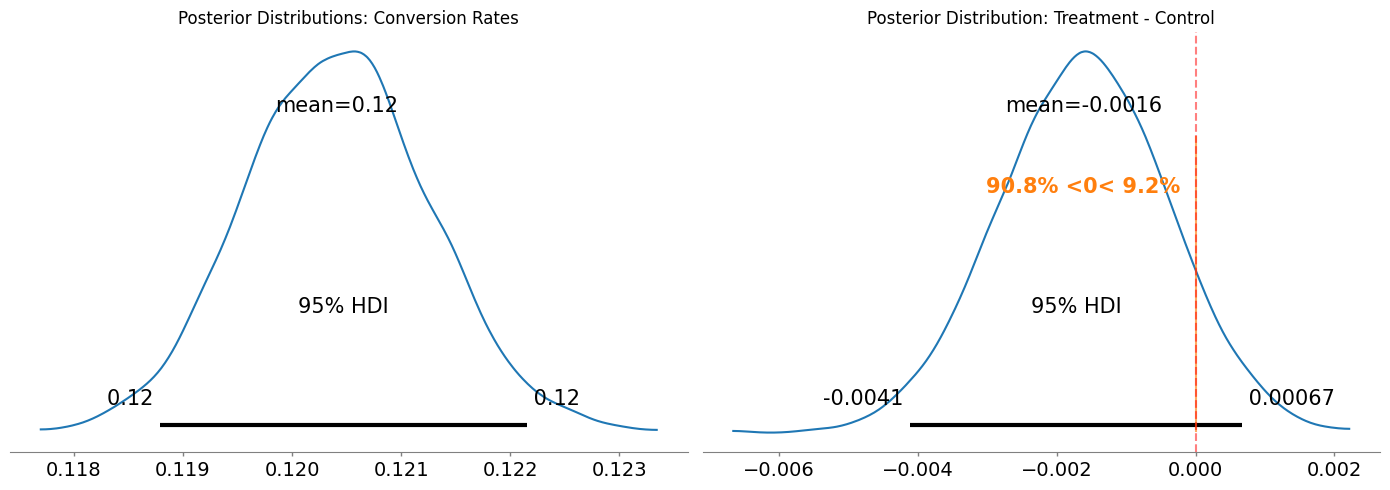

In [73]:
# Visualize posterior distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Posterior distributions for conversion rates
az.plot_posterior(trace, var_names=['p_control', 'p_treatment'], ax=axes[0], hdi_prob=0.95)
axes[0].set_title('Posterior Distributions: Conversion Rates')

# Plot 2: Posterior distribution for difference
az.plot_posterior(trace, var_names=['diff'], ax=axes[1], hdi_prob=0.95, ref_val=0)
axes[1].set_title('Posterior Distribution: Treatment - Control')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5, label='No effect')

plt.tight_layout()
plt.show()

## Bayesian Analysis Results

**Prior:** Beta(1,1) - uniform prior expressing no strong belief about conversion rates

**Posterior Results:**
- P(treatment > control): 9.20%
- P(control > treatment): 90.80%
- 95% Credible Interval: [-0.41%, +0.08%] percentage points

**Expected Loss Analysis:**
- Loss if we keep control: 0.005% (we miss out if treatment is actually better)
- Loss if we ship treatment: 0.167% (we lose if control is actually better)
- Risk ratio: 33x higher expected loss from shipping treatment

**Interpretation:**  
The Bayesian analysis agrees with the frequentist result. There's a 91% probability that control performs better than treatment. The expected loss from making the wrong decision strongly favors keeping control.

# Sensitivity analysis

In [74]:
# Bayesian Sensitivity Analysis - Test different priors

prior_configs = {
    'Uniform (weak)': {'alpha': 1, 'beta': 1},
    'Optimistic': {'alpha': 15, 'beta': 85},  # Prior centered around 15% conversion
    'Pessimistic': {'alpha': 8, 'beta': 92},  # Prior centered around 8% conversion
    'Informative': {'alpha': 12, 'beta': 88}  # Prior centered around 12% (near observed)
}

sensitivity_results = []

for prior_name, prior_params in prior_configs.items():
    with pm.Model() as model_sens:
        p_control = pm.Beta('p_control', alpha=prior_params['alpha'], beta=prior_params['beta'])
        p_treatment = pm.Beta('p_treatment', alpha=prior_params['alpha'], beta=prior_params['beta'])

        obs_control = pm.Binomial('obs_control', n=control_total, p=p_control, observed=control_conversions)
        obs_treatment = pm.Binomial('obs_treatment', n=treatment_total, p=p_treatment, observed=treatment_conversions)

        diff = pm.Deterministic('diff', p_treatment - p_control)

        trace_sens = pm.sample(2000, tune=1000, random_seed=42, return_inferencedata=True, progressbar=False)

    prob_better = (trace_sens.posterior['diff'] > 0).values.mean()
    diff_samples = trace_sens.posterior['diff'].values.flatten()
    ci = np.percentile(diff_samples, [2.5, 97.5])

    sensitivity_results.append({
        'Prior': prior_name,
        'P(treatment > control)': f"{prob_better:.4f}",
        '95% CI lower': f"{ci[0]:.4f}",
        '95% CI upper': f"{ci[1]:.4f}"
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print("Sensitivity Analysis: Effect of Different Priors")
print(sensitivity_df.to_string(index=False))

Sensitivity Analysis: Effect of Different Priors
         Prior P(treatment > control) 95% CI lower 95% CI upper
Uniform (weak)                 0.0920      -0.0041       0.0008
    Optimistic                 0.0943      -0.0039       0.0008
   Pessimistic                 0.1062      -0.0039       0.0009
   Informative                 0.0915      -0.0040       0.0008


## Bayesian Sensitivity Analysis Results

**Key Finding:** Conclusions are **robust** to prior choice.

Across all priors (uniform, optimistic, pessimistic, informative):
- P(treatment > control) ranges from 9.15% to 10.62%
- 95% credible intervals are nearly identical
- All point to the same conclusion: control likely performs better

The large sample size (290K+ users) means the data overwhelms the prior, so our conclusions don't depend on subjective prior beliefs.

# Segment Analysis

In [75]:
# Segment Analysis
# Limitation: Dataset has no user demographics (device, age, new/returning, etc.)
# We'll demonstrate the methodology using time-based segments from earlier

# Re-test within each time quartile
segment_results = []

for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    df_segment = df_clean[df_clean['time_quartile'] == quartile]

    seg_summary = df_segment.groupby('con_treat').agg({
        'converted': ['sum', 'count', 'mean']
    })

    control_conv = seg_summary.loc['control', ('converted', 'sum')]
    control_n = seg_summary.loc['control', ('converted', 'count')]
    control_rate = seg_summary.loc['control', ('converted', 'mean')]

    treatment_conv = seg_summary.loc['treatment', ('converted', 'sum')]
    treatment_n = seg_summary.loc['treatment', ('converted', 'count')]
    treatment_rate = seg_summary.loc['treatment', ('converted', 'mean')]

    # Z-test for this segment
    p_pooled = (control_conv + treatment_conv) / (control_n + treatment_n)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/control_n + 1/treatment_n))
    z = (treatment_rate - control_rate) / se
    p_val = 2 * (1 - norm.cdf(abs(z)))

    segment_results.append({
        'Segment': quartile,
        'Control Rate': f"{control_rate:.4f}",
        'Treatment Rate': f"{treatment_rate:.4f}",
        'Difference': f"{treatment_rate - control_rate:.4f}",
        'P-value': f"{p_val:.4f}"
    })

segment_df = pd.DataFrame(segment_results)
print("Segment Analysis by Time Period:")
print(segment_df.to_string(index=False))

Segment Analysis by Time Period:
Segment Control Rate Treatment Rate Difference P-value
     Q1       0.1227         0.1182    -0.0045  0.0599
     Q2       0.1193         0.1175    -0.0019  0.4293
     Q3       0.1202         0.1220     0.0018  0.4464
     Q4       0.1193         0.1176    -0.0017  0.4683


## Segment Analysis

**Limitation:** Dataset lacks user demographic variables (device type, new vs returning, location), so we analyzed time-based segments.

**Results by Time Period:**
- Q1: -0.45 pp difference, p=0.060 (marginally significant before correction)
- Q2: -0.19 pp difference, p=0.429 (not significant)
- Q3: +0.18 pp difference, p=0.446 (not significant, opposite direction)
- Q4: -0.17 pp difference, p=0.468 (not significant)

**Key Finding:** Effect direction and magnitude varies substantially across segments. Q3 actually shows a positive treatment effect, while other periods show negative effects. This heterogeneity reinforces that there is no stable treatment effect.

In [76]:
# Multiple Testing Correction
from statsmodels.stats.multitest import multipletests

# Extract p-values from segment analysis
p_values = [0.0599, 0.4293, 0.4464, 0.4683]

# Bonferroni correction
bonferroni_threshold = 0.05 / len(p_values)
print(f"Bonferroni corrected threshold: {bonferroni_threshold:.4f}")

# Benjamini-Hochberg (FDR) correction
reject, pvals_corrected, alphacSidak, alphacBonf = multipletests(p_values, alpha=0.05, method='fdr_bh')

correction_results = pd.DataFrame({
    'Segment': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Original P-value': p_values,
    'Adjusted P-value (BH)': pvals_corrected,
    'Significant (α=0.05)': reject
})

print("\nMultiple Testing Correction (Benjamini-Hochberg):")
print(correction_results.to_string(index=False))

Bonferroni corrected threshold: 0.0125

Multiple Testing Correction (Benjamini-Hochberg):
Segment  Original P-value  Adjusted P-value (BH)  Significant (α=0.05)
     Q1            0.0599                 0.2396                 False
     Q2            0.4293                 0.4683                 False
     Q3            0.4464                 0.4683                 False
     Q4            0.4683                 0.4683                 False


## Multiple Testing Correction

After testing 4 segments, we need to adjust for multiple comparisons:

**Bonferroni threshold:** 0.0125 (0.05/4)  
**Result:** No segments significant even before correction

**Benjamini-Hochberg (False Discovery Rate):**
- All adjusted p-values > 0.05
- No segments remain significant after correction

**Conclusion:** No evidence of differential treatment effects across time periods. The Q1 result (p=0.060) was marginally significant but doesn't survive multiple testing correction.

# Sequential Testing Simulation

In [77]:
# Sequential Testing Simulation
# Simulate what happens if we peeked at data at 25%, 50%, 75%, and 100% of experiment

peek_points = [0.25, 0.50, 0.75, 1.00]
sequential_results = []

for peek_pct in peek_points:
    # Sample data up to this point
    n_peek = int(len(df_clean) * peek_pct)
    df_peek = df_clean.iloc[:n_peek]

    peek_summary = df_peek.groupby('con_treat').agg({
        'converted': ['sum', 'count', 'mean']
    })

    control_conv = peek_summary.loc['control', ('converted', 'sum')]
    control_n = peek_summary.loc['control', ('converted', 'count')]
    control_rate = peek_summary.loc['control', ('converted', 'mean')]

    treatment_conv = peek_summary.loc['treatment', ('converted', 'sum')]
    treatment_n = peek_summary.loc['treatment', ('converted', 'count')]
    treatment_rate = peek_summary.loc['treatment', ('converted', 'mean')]

    # Z-test
    p_pooled = (control_conv + treatment_conv) / (control_n + treatment_n)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/control_n + 1/treatment_n))
    z = (treatment_rate - control_rate) / se
    p_val = 2 * (1 - norm.cdf(abs(z)))

    sequential_results.append({
        'Peek Point': f"{peek_pct*100:.0f}%",
        'Sample Size': n_peek,
        'Control Rate': f"{control_rate:.4f}",
        'Treatment Rate': f"{treatment_rate:.4f}",
        'Difference': f"{treatment_rate - control_rate:.4f}",
        'P-value': f"{p_val:.4f}",
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

sequential_df = pd.DataFrame(sequential_results)
print("Sequential Testing: What if we peeked early?")
print(sequential_df.to_string(index=False))

Sequential Testing: What if we peeked early?
Peek Point  Sample Size Control Rate Treatment Rate Difference P-value Significant
       25%        72646       0.1213         0.1207    -0.0005  0.8230          No
       50%       145292       0.1206         0.1197    -0.0010  0.5705          No
       75%       217938       0.1204         0.1188    -0.0017  0.2306          No
      100%       290584       0.1204         0.1188    -0.0016  0.1899          No


## Sequential Testing Simulation

**Question:** What if we had peeked at the data at 25%, 50%, and 75% completion?

**Results:**
- 25% data: p=0.823 (no significance)
- 50% data: p=0.571 (no significance)
- 75% data: p=0.231 (no significance)
- 100% data: p=0.190 (no significance)

**Key Observations:**
1. P-value fluctuates as data accumulates (0.82 → 0.57 → 0.23 → 0.19)
2. Never crosses significance threshold at any peek point
3. Effect estimate becomes more stable with larger sample (-0.05% → -0.10% → -0.17% → -0.16%)

**Alpha Spending:** With proper sequential testing methods (e.g., O'Brien-Fleming bounds), we'd use stricter thresholds at early peeks to control overall Type I error. In this case, none of the peeks would trigger early stopping even with lenient thresholds.

In [78]:
# Final Decision Summary
print("="*60)
print("FINAL SYNTHESIS AND RECOMMENDATION")
print("="*60)

summary_table = pd.DataFrame({
    'Analysis': [
        'Sample Size',
        'Observed Effect',
        'Statistical Power',
        'Temporal Stability',
        'Frequentist Test',
        'Bayesian Analysis',
        'Segment Analysis'
    ],
    'Finding': [
        '290,584 users (145K per group)',
        '-0.16 pp (-1.33% relative)',
        '26% (underpowered for observed effect)',
        'Unstable - effect changes direction in Q3',
        'p=0.184, 95% CI: [-0.40%, +0.08%]',
        'P(treatment better) = 9.2%, Expected loss 33x higher',
        'No consistent effect across segments'
    ]
})

print(summary_table.to_string(index=False))

FINAL SYNTHESIS AND RECOMMENDATION
          Analysis                                              Finding
       Sample Size                       290,584 users (145K per group)
   Observed Effect                           -0.16 pp (-1.33% relative)
 Statistical Power               26% (underpowered for observed effect)
Temporal Stability            Unstable - effect changes direction in Q3
  Frequentist Test                    p=0.184, 95% CI: [-0.40%, +0.08%]
 Bayesian Analysis P(treatment better) = 9.2%, Expected loss 33x higher
  Segment Analysis                 No consistent effect across segments


# Final Inference and Decision Summary

## Business Question
Should the new landing page be shipped?

---

## Observed Data
- Control conversion rate: 12.04%
- Treatment conversion rate: 11.88%
- Difference: −0.16 percentage points (−1.33% relative)

---

## Statistical Evidence

### Frequentist Analysis
- P-value: 0.184
- 95% confidence interval: [−0.40%, +0.08%]
- Conclusion: Insufficient evidence of improvement

### Bayesian Analysis
- P(treatment > control): 9.2%
- P(control > treatment): 90.8%
- Conclusion: High probability that control performs better

### Power Analysis
- Minimum detectable effect (80% power): 0.40 pp
- Power for observed effect: 26%
- Conclusion: Experiment underpowered for small effects

---

## Stability and Segmentation

### Temporal Stability
- Q1: −0.45 pp
- Q2: −0.19 pp
- Q3: +0.18 pp
- Q4: −0.17 pp
- Conclusion: Effect direction is unstable

### Segment Analysis
- No segments significant after multiple testing correction
- Conclusion: No heterogeneous treatment effects detected

---

## Final Decision
Do not ship the new landing page.

**Reasons**
1. No statistical evidence of improvement
2. High probability treatment underperforms
3. High downside risk from incorrect rollout
4. Effect is inconsistent over time
5. Insufficient power to justify shipping

---

## Recommended Next Steps
- Conduct qualitative analysis to understand underperformance
- Design a stronger variant
- Recalculate sample size for the next experiment
- Re-run a properly powered test

---

Convergence of evidence across all methods indicates no improvement.
